In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("pypdf").setLevel(logging.ERROR)

In [2]:
# cd notebook
# jupyter lab

This approach is being followed
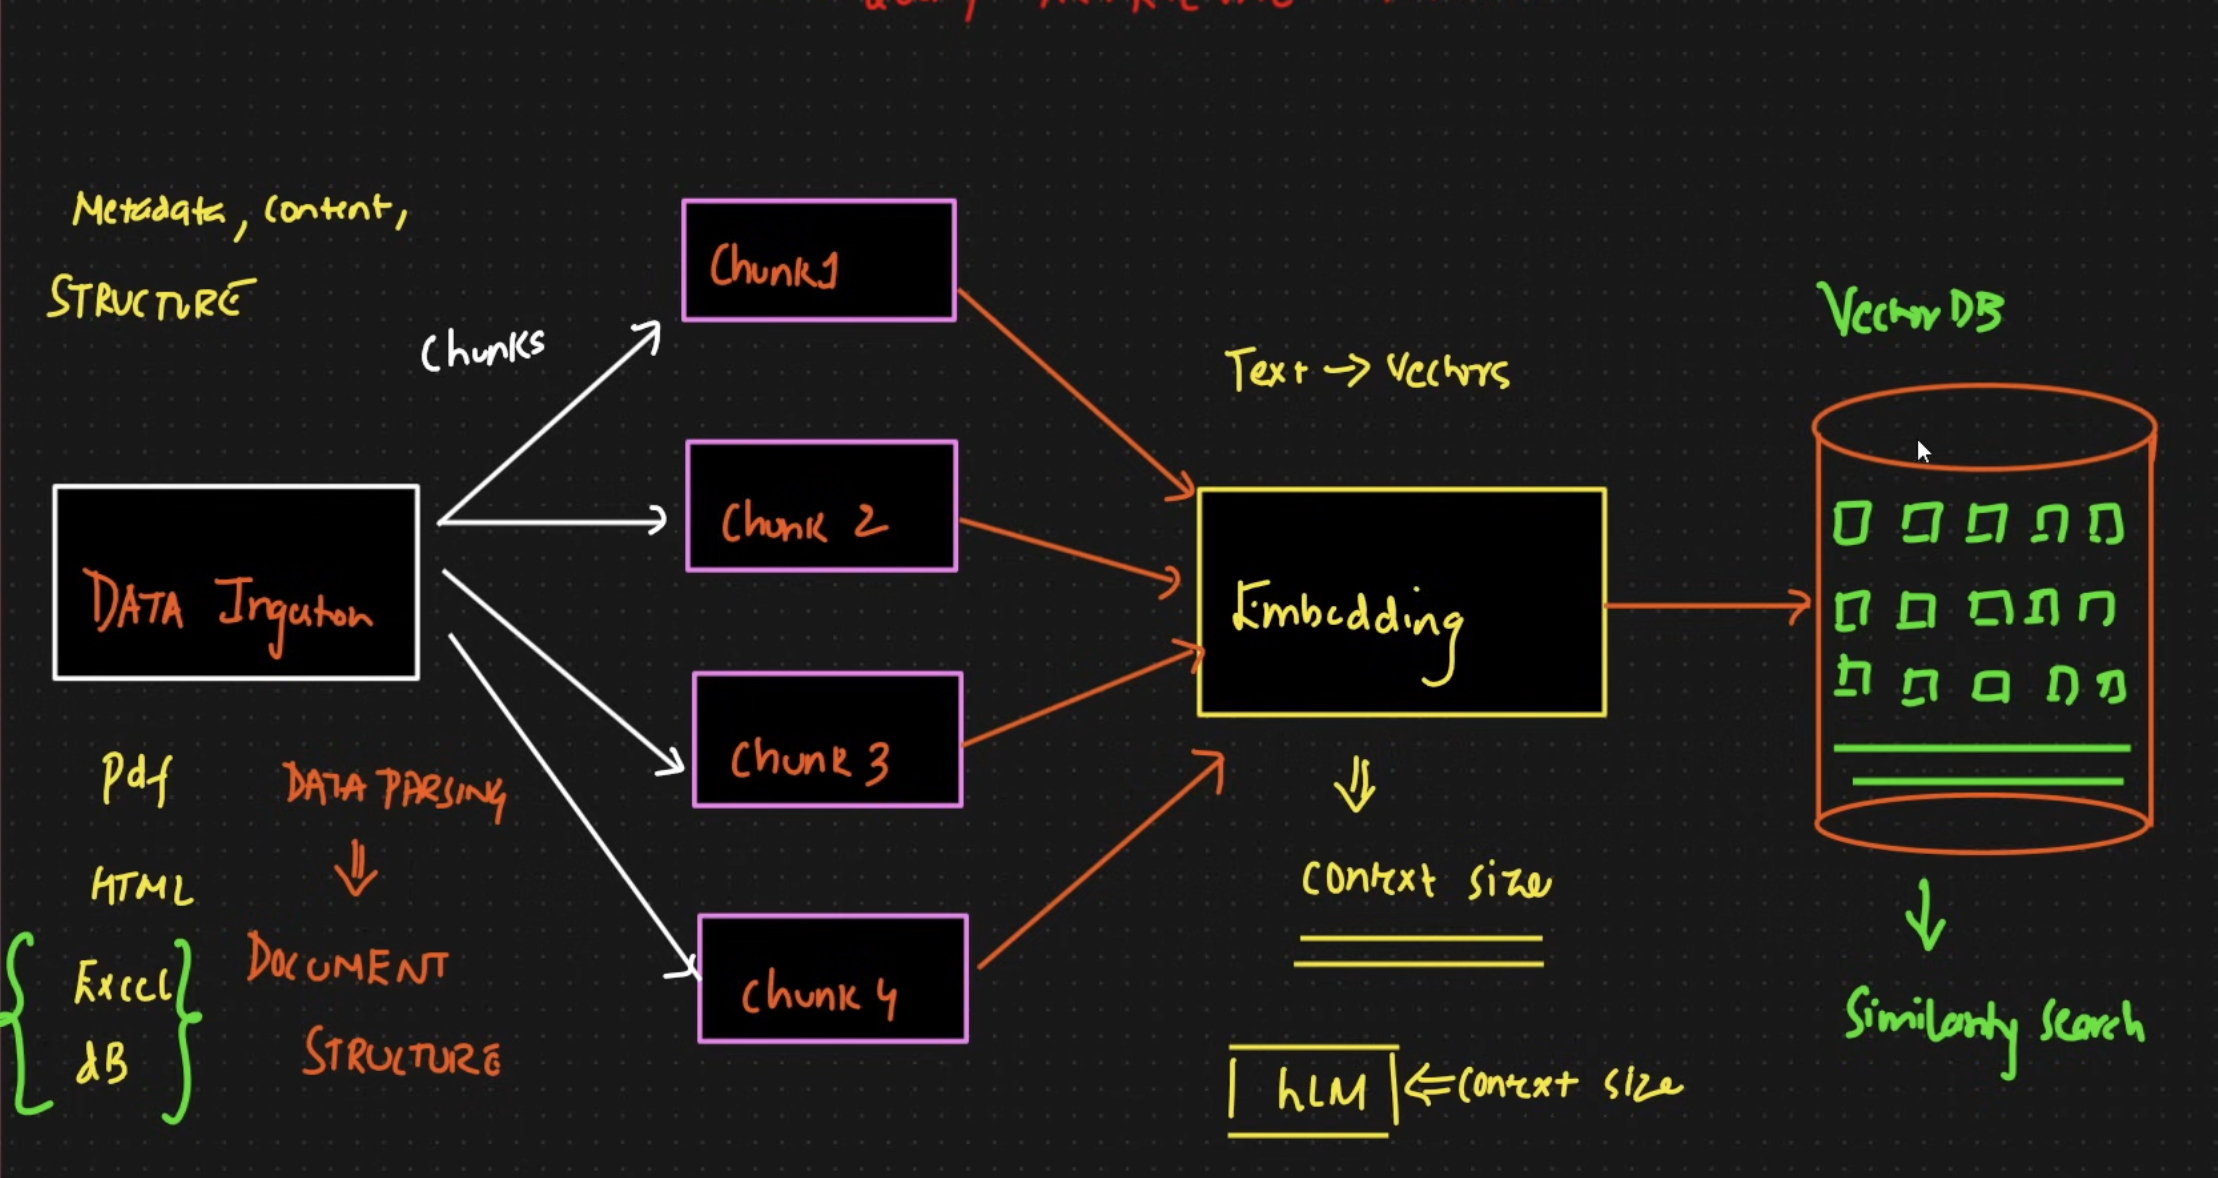

### RAG Pipelines : Data Ingestion to Vector DB

In [3]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

In [4]:
### Read all the pdf's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)

    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))

    print(f"Found {len(pdf_files)} PDF files to process")

    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()

            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'

            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")

        except Exception as e:
            print(f"  ✗ Error: {e}")

    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory
all_pdf_documents = process_all_pdfs("../data")

Found 4 PDF files to process

Processing: paper.pdf
  ✓ Loaded 15 pages

Processing: Mumuksha Pant Resume.pdf
  ✓ Loaded 1 pages

Processing: Turo.pdf
  ✓ Loaded 2 pages

Processing: L01_notes.pdf
  ✓ Loaded 10 pages

Total documents loaded: 28


### Chunking

In [5]:
import numpy as np
from sentence_transformers import SentenceTransformer #embedding model is available here 
import chromadb #vector DB
from chromadb.config import Settings
import uuid # to generate unique ID for every record
from typing import List, Dict, Any, Tuple 
from sklearn.metrics.pairwise import cosine_similarity # for similarity score

In [6]:
### Text splitting get into chunks using RecursiveCharacterTextSplitter

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [7]:
chunks=split_documents(all_pdf_documents)
chunks[173]

Split 28 documents into 174 chunks

Example chunk:
Content: Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
...
Metadata: {'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/pdf/paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'paper.pdf', 'file_type': 'pdf'}


Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20260603012818', 'source': '../data/pdf/L01_notes.pdf', 'total_pages': 10, 'page': 9, 'page_label': '10', 'source_file': 'L01_notes.pdf', 'file_type': 'pdf'}, page_content='10 CHAPTER 1. ENCODING INFORMATION\n(b) Using Huffman’s algorithm, construct a variable-length code assuming that\neach vowel is encoded individually. Please draw a diagram of the Huffman\ntree and give the encoding for each of the vowels.\n(c) Using your code from part (B) above, give an expression for the expected length\nin bits of an encoded message transmitting 100 vowels.\n(d) Ben Bitdiddle spends all night working on a more complicated encoding algo-\nrithm and sends you email claiming that using his code the expected length in\nbits of an encoded message transmitting 100 vowels is 197 bits. Would you pay\ngood money for his implementation?')

In [8]:
# chunks

### Embedding And vectorStoreDB

In [9]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise

    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts

        Args: texts: List of text strings to embed
        Returns:numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings



## initialize the embedding manager
embedding_manager=EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 9751.99it/s]


Model loaded successfully. Embedding dimension: 384


### Vector Store 
A vector store is a database that stores embeddings and retrieves similar text based on meaning, not exact words

Vector stores are used to:
* store document chunks
* retrieve relevant chunks for the LLM

In [10]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True) # Save embeddings on disk
            self.client = chromadb.PersistentClient(path=self.persist_directory) 
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG",
                         "hnsw:space": "cosine"
                         }
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        For each document:
            - Generates unique ID
            - Stores text (page_content)
            - Stores metadata (source info, length, etc.)
            - Stores embedding vector
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 174


In [11]:
chunks[173]

Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20260603012818', 'source': '../data/pdf/L01_notes.pdf', 'total_pages': 10, 'page': 9, 'page_label': '10', 'source_file': 'L01_notes.pdf', 'file_type': 'pdf'}, page_content='10 CHAPTER 1. ENCODING INFORMATION\n(b) Using Huffman’s algorithm, construct a variable-length code assuming that\neach vowel is encoded individually. Please draw a diagram of the Huffman\ntree and give the encoding for each of the vowels.\n(c) Using your code from part (B) above, give an expression for the expected length\nin bits of an encoded message transmitting 100 vowels.\n(d) Ben Bitdiddle spends all night working on a more complicated encoding algo-\nrithm and sends you email claiming that using his code the expected length in\nbits of an encoded message transmitting 100 vowels is 197 bits. Would you pay\ngood money for his implementation?')

In [12]:
### Convert the text to embeddings
texts=[doc.page_content for doc in chunks]

## Generate the Embeddings
embeddings=embedding_manager.generate_embeddings(texts)

##store int he vector dtaabase
vectorstore.add_documents(chunks,embeddings)

Generating embeddings for 174 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00,  6.78it/s]


Generated embeddings with shape: (174, 384)
Adding 174 documents to vector store...
Successfully added 174 documents to vector store
Total documents in collection: 348


In [13]:
embeddings

array([[-0.11415933, -0.1280181 ,  0.03414959, ...,  0.08499363,
        -0.01825304, -0.0511776 ],
       [-0.05045886, -0.09457841,  0.03290998, ...,  0.02575778,
        -0.09101799, -0.01993199],
       [-0.02352396, -0.12380515,  0.02611263, ...,  0.07987245,
        -0.05718822,  0.00957778],
       ...,
       [ 0.04119468,  0.08873209, -0.09204266, ...,  0.02452201,
        -0.0830983 , -0.05570481],
       [ 0.01205946,  0.03413267, -0.03414931, ...,  0.06484355,
         0.01736195, -0.08251288],
       [-0.00561098,  0.08393293,  0.00621302, ...,  0.02962158,
        -0.02628484, -0.0533011 ]], shape=(174, 384), dtype=float32)

In [14]:
### To see whats inside the vector store DB

In [15]:
import sqlite3

conn = sqlite3.connect("/Users/mpant/personal-projects/rag-sandbox/data/vector_store/chroma.sqlite3")
cursor = conn.cursor()
cursor.execute("SELECT * from collections LIMIT 1;")
rows = cursor.fetchall()

rows

[('7aefb526-52e1-40c2-8b84-ecedf3678c34',
  'pdf_documents',
  384,
  '00000000-0000-0000-0000-000000000000',
  '{}',
  '{"defaults":{"string":{"fts_index":{"enabled":false,"config":{}},"string_inverted_index":{"enabled":true,"config":{}}},"float_list":{"vector_index":{"enabled":false,"config":{"space":"cosine","embedding_function":{"type":"known","name":"default","config":{}},"hnsw":{"ef_construction":100,"max_neighbors":16,"ef_search":100,"num_threads":10,"batch_size":100,"sync_threshold":1000,"resize_factor":1.2}}}},"sparse_vector":{"sparse_vector_index":{"enabled":false,"config":{"embedding_function":{"type":"unknown"},"bm25":false}}},"int":{"int_inverted_index":{"enabled":true,"config":{}}},"float":{"float_inverted_index":{"enabled":true,"config":{}}},"bool":{"bool_inverted_index":{"enabled":true,"config":{}}}},"keys":{"keywords":{"string":{"fts_index":{"enabled":false,"config":{}},"string_inverted_index":{"enabled":true,"config":{}}}},"page":{"int":{"int_inverted_index":{"enabled

In [16]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_sql_query(
    "SELECT * FROM collections",
    conn
)

import json

print(json.dumps(json.loads(df.iloc[0]["schema_str"]), indent=3))

'''
There are total 384 chunks of the documents. 

Chroma supports: 
    Vector search (meaning search)
    Text search (keyword search)
'''

{
   "defaults": {
      "string": {
         "fts_index": {
            "enabled": false,
            "config": {}
         },
         "string_inverted_index": {
            "enabled": true,
            "config": {}
         }
      },
      "float_list": {
         "vector_index": {
            "enabled": false,
            "config": {
               "space": "cosine",
               "embedding_function": {
                  "type": "known",
                  "name": "default",
                  "config": {}
               },
               "hnsw": {
                  "ef_construction": 100,
                  "max_neighbors": 16,
                  "ef_search": 100,
                  "num_threads": 10,
                  "batch_size": 100,
                  "sync_threshold": 1000,
                  "resize_factor": 1.2
               }
            }
         }
      },
      "sparse_vector": {
         "sparse_vector_index": {
            "enabled": false,
            "config": {
    

'\nThere are total 384 chunks of the documents. \n\nChroma supports: \n    Vector search (meaning search)\n    Text search (keyword search)\n'

### Our Pipeline steps our complete as per diagram, now next step is Retrieval

User Query
   
    ↓
    
Convert query to embedding
    
    ↓

Search vector database

    ↓

Return most similar document chunks


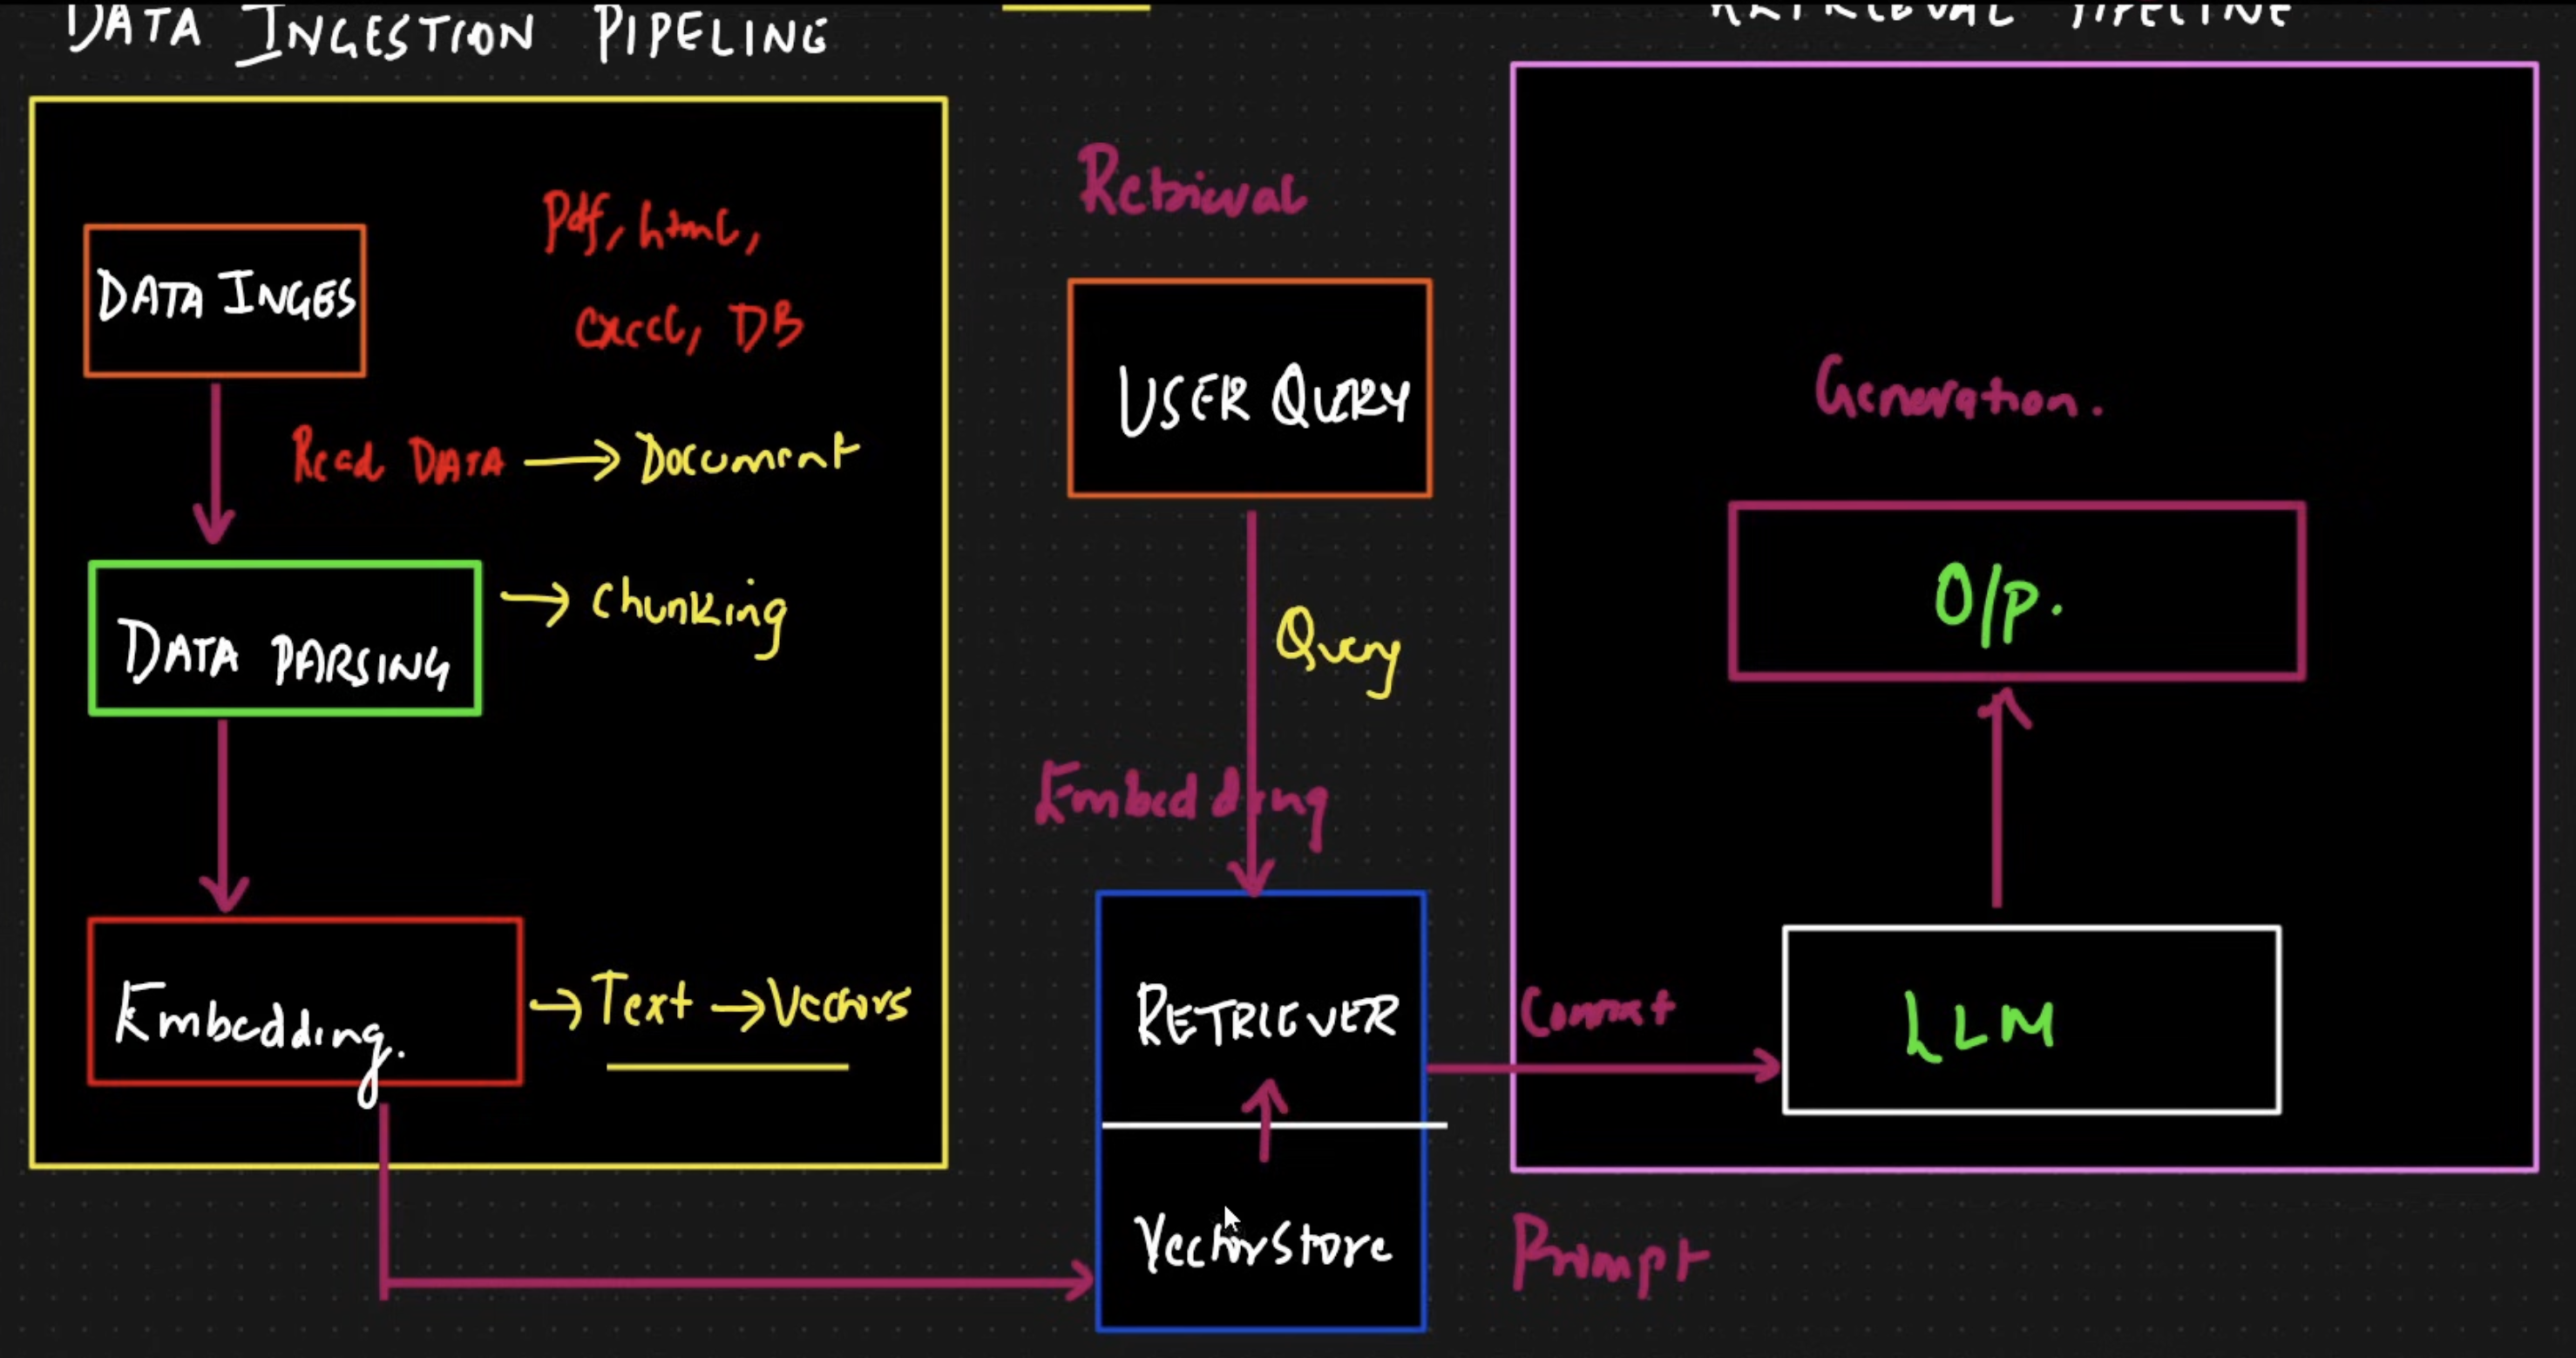

### Retriever Pipeline From VectorStore

In [17]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
            vector_store: Vector store containing document embeddings, eg Chunk 1 -> [0.1, 0.4, ...] stored in ChromaDB
            embedding_manager: Used to convert user queries into embeddings.
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager # Used to convert user queries into embeddings. Ex : "What is a transformer model?" becomes [0.42, -0.15, 0.91, ...]
        




    '''
    Example : 
    STEP 1 : Stored chunks are :
        Chunk A: "Machine learning is a subset of AI"
        Chunk B: "Neural networks use weighted connections"
        Chunk C: "The weather today is sunny"
    

    STEP 2 : Search Chroma DB 
        results = self.vector_store.collection.query(.. ) performs vector similarity search.
        Query: "What is machine learning?"
    
        The vector database might return the following ranked by similarity:
        Chunk A
        Chunk B
        Chunk C

    STEP 3  : Chroma returns something like:
        {
            'documents': [[...]],
            'metadatas': [[...]],
            'distances': [[...]],
            'ids': [[...]]
        }

    STEP 4: Extract Results ( because Chroma returns a nested list ) 
        documents = results['documents'][0]
        metadatas = results['metadatas'][0]
        distances = results['distances'][0]
        ids = results['ids'][0]

        After extraction: documents = [
                                        "Machine learning is...",
                                        "Neural networks are..."
                                        ]

    STEP 5 : Loop through Matches --Processes each retrieved chunk.
    
    STEP 6: Convert Distance to Similarity -- Higher similarity is better.
            This is because Chroma returns distance, not similarity.

            Example:
            Distance	Similarity
            0.05	   0.95
            0.10	   0.90
            0.50	   0.50

    STEP 7: Apply Threshold
    

    '''
    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]
        
        # Search in vector store ---This performs vector similarity search.
        try:
            results = self.vector_store.collection.query( 
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )
            
            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)

In [18]:
rag_retriever.retrieve("What is mumuksha's professsion?") # This is our context that we will pass to our LLM 
# "context" is the relevant text chunks you pulled from your documents and are handing to the LLM alongside the question. 

Retrieving documents for query: 'What is mumuksha's professsion?'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 25.47it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_6ad084d3_63',
  'content': 'As you already know my name is Mumuksha Pant. I graduated from Northeastern University last year with a Masters in Computer Sciences. I bring about 4 years of experience in software development and data engineering .Its been almost a year that I have been working with Addgene as a Data Engineer 2. Addgene is a non profit plasmid repository that is focused on advancing genetic research. Prior to my Masters, I have worked for about 3 years in India for an electric ride hailing company.I worked on end-to-end backend microservicesusing Java and Spring Boot that powered rider-facing features for 1.47M+ users and ~15K daily rides.Currently in Addgene, I am working extensively on python and django and exploring a completely new domain of data engineering because I have always worked as a Software Developer before.By way of my technical background, I have working experience with Python,  SQL, Django and Cloud Platforms like GCP , AWS, Azure. I have had 

In [19]:
# Bypass everything and query ChromaDB directly
query_embedding = embedding_manager.generate_embeddings(["What is mumuksha's profession?"])[0]

raw = vectorstore.collection.query(
    query_embeddings=[query_embedding.tolist()],
    n_results=5
)

print("Documents returned:", len(raw["documents"][0]))
print("\nDistances:", raw["distances"][0])
print("\nFirst doc preview:", raw["documents"][0][0][:200] if raw["documents"][0] else "EMPTY")

Generating embeddings for 1 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 19.27it/s]

Generated embeddings with shape: (1, 384)
Documents returned: 5

Distances: [0.7770573496818542, 0.7770573496818542, 0.7770573496818542, 0.7770573496818542, 0.8105747699737549]

First doc preview: As you already know my name is Mumuksha Pant. I graduated from Northeastern University last year with a Masters in Computer Sciences. I bring about 4 years of experience in software development and da


### Testing

In [20]:
q = embedding_manager.generate_embeddings(["What is Mumuksha's profession"])[0]
raw = vectorstore.collection.query(query_embeddings=[q.tolist()], n_results=5)
print("count in collection:", vectorstore.collection.count())
print("distances:", raw["distances"])
print("docs returned:", len(raw["documents"][0]) if raw["documents"] else 0)

Generating embeddings for 1 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 32.01it/s]

Generated embeddings with shape: (1, 384)
count in collection: 348
distances: [[0.7908595204353333, 0.7908595204353333, 0.7908595204353333, 0.7908595204353333, 0.8428163528442383]]
docs returned: 5


In [21]:
# #Testing 
# hits = [c for c in chunks if "Mumuksha" in c.page_content]
# print(len(hits))

In [22]:
v = embedding_manager.model.encode(["Mumuksha"])
print(type(v), v.shape)
print(v[0][:10])   # should be 10 DIFFERENT floats
print(len(set(v[0].tolist())))   # should be ~384, not 1

<class 'numpy.ndarray'> (1, 384)
[-0.02806095  0.01193892 -0.01207475  0.03330047 -0.06886503 -0.00941589
  0.05225945 -0.00858805  0.01978384 -0.0176441 ]
384


In [23]:
result = embedding_manager.generate_embeddings(["Mumuksha"])
print(type(result), getattr(result, "shape", None))
print(result[0][:10])

Generating embeddings for 1 texts...


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 121.71it/s]

Generated embeddings with shape: (1, 384)
<class 'numpy.ndarray'> (1, 384)
[-0.02806095  0.01193892 -0.01207475  0.03330047 -0.06886503 -0.00941589
  0.05225945 -0.00858805  0.01978384 -0.0176441 ]


### Query Retrieval Pipeline - VectorDB + LLM Output Generation
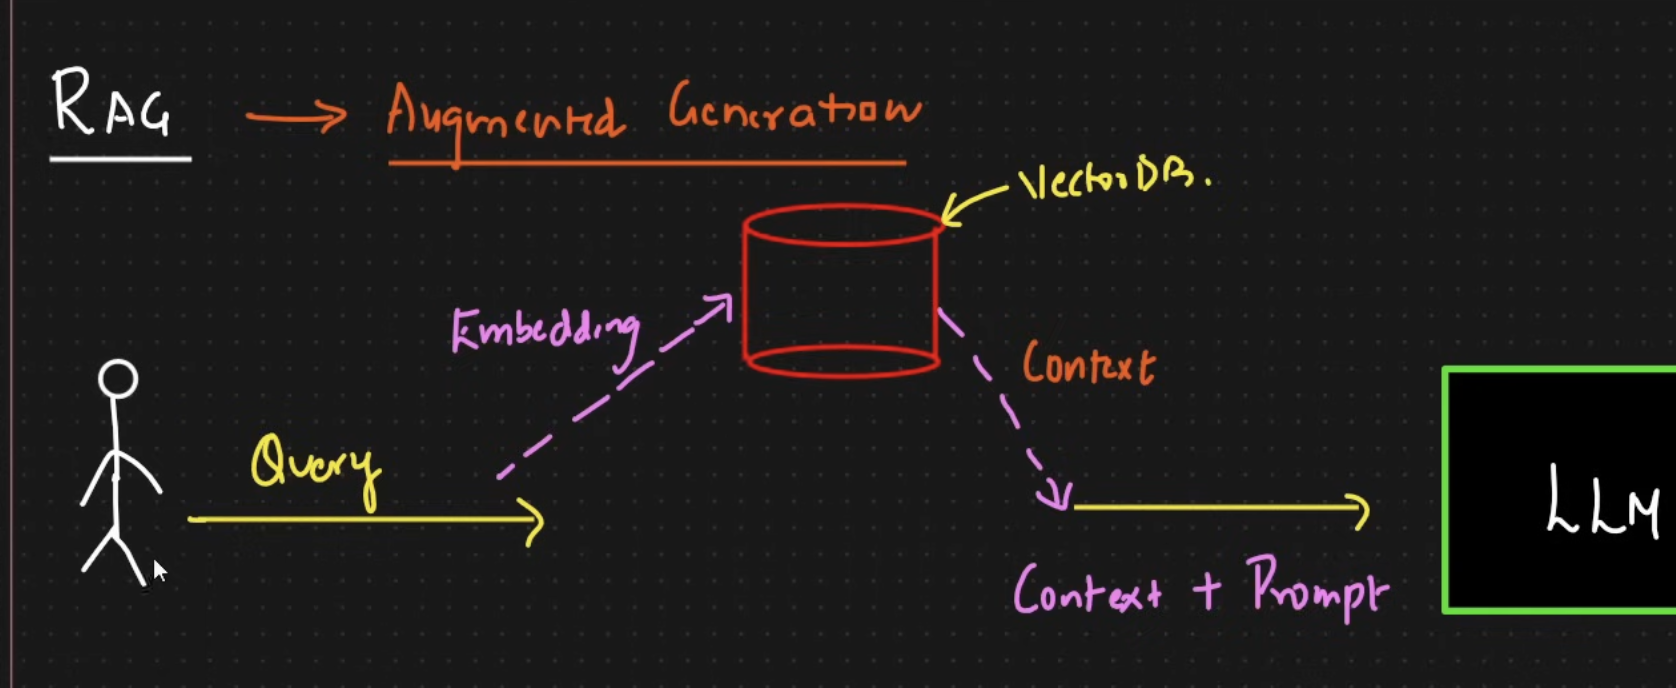

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

# print(os.getenv("GROQ_API_KEY"))

True

In [25]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage

In [26]:
class GroqLLM:
    def __init__(self, model_name: str = "gemma2-9b-it", api_key: str =None):
        """
        Initialize Groq LLM
        
        Args:
            model_name: Groq model name (qwen2-72b-instruct, llama3-70b-8192, etc.)
            api_key: Groq API key 
        """
        self.model_name = model_name
        self.api_key = api_key or os.environ.get("GROQ_API_KEY")
        
        if not self.api_key:
            raise ValueError("Groq API key is required.")
        
        self.llm = ChatGroq(
            groq_api_key=self.api_key,
            model_name=self.model_name,
            temperature=0.1,
            max_tokens=1024
        )
        
        print(f"Initialized Groq LLM with model: {self.model_name}")

    

    # "context" is the relevant text chunks you pulled from your documents and are handing to the LLM alongside the question. 
    # context generated using ::     `rag_retriever.retrieve("..")`
    def generate_response(self, query: str, context: str, max_length: int = 500) -> str:
        """
        Generate response using retrieved context
        Returns:
            Generated response string
        """
        
        # Create prompt template
        prompt_template = PromptTemplate(
            input_variables=["context", "question"],
            template="""You are a helpful AI assistant. Use the following context as your primary source, and supplement with your own knowledge where the context is incomplete.
            Context:
            {context}
            
            Question: {question}
            
            Answer:"""
        )

        # Format the prompt
        formatted_prompt = prompt_template.format(context=context, question=query)
        
        try:
            # Generate response
            messages = [HumanMessage(content=formatted_prompt)]
            response = self.llm.invoke(messages)
            return response.content
            
        except Exception as e:
            return f"Error generating response: {str(e)}"


    
    def generate_response_simple(self, query: str, context: str) -> str:
        """
        Simple response generation without complex prompting            
        Returns:
            Generated response
        """
        simple_prompt = f"""Based on this context: {context}
        Question: {query}
        Answer:"""
        
        try:
            messages = [HumanMessage(content=simple_prompt)]
            response = self.llm.invoke(messages) #
            return response.content
        except Exception as e:
            return f"Error: {str(e)}"

In [27]:
# Testing Groq 
llm = GroqLLM(model_name="llama-3.3-70b-versatile")

print(
    llm.generate_response_simple(
        query="What is Mumuksha's profession?",
        context="DNA is a molecule that carries genetic information."
    )
)

Initialized Groq LLM with model: llama-3.3-70b-versatile
There is no information provided about Mumuksha's profession. The given context only talks about DNA and its role in carrying genetic information, but it does not mention Mumuksha or any profession.


### Integration Vectordb Context pipeline With LLM output

In [28]:
### Simple RAG pipeline with Groq LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

llm = GroqLLM(model_name="llama-3.3-70b-versatile")


## Simple RAG function: retrieve context + generate response
def rag_simple(query,retriever,llm,top_k=3):
    
    results=retriever.retrieve(query,top_k=top_k) # context
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found to answer the question."
    
    return llm.generate_response(query=query, context=context)


Initialized Groq LLM with model: llama-3.3-70b-versatile


In [34]:
user_query2= "Does Mumuksha have enough experience to apply for a Director Level Engineer role? What gaps might she need to fill?"
answer2=rag_simple(user_query2, rag_retriever, llm)
print(answer2)

Retrieving documents for query: 'Does Mumuksha have enough experience to apply for a Director Level Engineer role? What gaps might she need to fill?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 19.40it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


Based on the provided context, Mumuksha Pant has around 4 years of experience in software development and data engineering, with a Master's degree in Computer Sciences from Northeastern University. While she has worked on various technologies such as Python, SQL, Django, and cloud platforms like GCP, AWS, and Azure, her experience is relatively limited compared to what is typically expected for a Director Level Engineer role.

Typically, a Director Level Engineer role requires around 10-15 years of experience, with a strong track record of technical leadership, strategic planning, and team management. Mumuksha's current experience as a Data Engineer 2 at Addgene, although valuable, may not be sufficient to qualify her for a Director Level Engineer role.

Some gaps that Mumuksha might need to fill to be considered for a Director Level Engineer role include:

1. **Leadership experience**: Mumuksha may need to gain experience in leading teams, mentoring engineers, and driving technical st

In [31]:
from typing import Dict, Any

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []

    def query(
        self,
        question: str,
        top_k: int = 5,
        min_score: float = 0.2,
        summarize: bool = False
    ) -> Dict[str, Any]:

        results = self.retriever.retrieve(
            question,
            top_k=top_k,
            score_threshold=min_score
        )

        if not results:
            answer = "No relevant context found."
            sources = []
        else:
            context = "\n\n".join([doc["content"] for doc in results])

            sources = [
                {
                    "source": doc["metadata"].get(
                        "source_file",
                        doc["metadata"].get("source", "unknown")
                    ),
                    "page": doc["metadata"].get("page", "unknown"),
                    "score": round(doc["similarity_score"], 3),
                    "preview": doc["content"][:120] + "..."
                }
                for doc in results
            ]

            answer = self.llm.generate_response(
                query=question,
                context=context
            )

        # Add citations
        citations = [
            f"[{i+1}] {src['source']} (page {src['page']})"
            for i, src in enumerate(sources)
        ]
        answer_with_citations = (
            answer + "\n\nCitations:\n" + "\n".join(citations)
            if citations
            else answer
        )

        # Optional summarization — no document context needed here
        summary = None
        if summarize and answer:
            summary = self.llm.generate_response_simple(
                query=f"Summarize the following answer in 2 concise sentences: {answer}",
                context=""
            )

        self.history.append({
            "question": question,
            "answer": answer,
            "sources": sources,
            "summary": summary
        })

        return {
            "question": question,
            "answer": answer_with_citations,
            "sources": sources,
            "summary": summary,
            "history": self.history
        }

In [32]:
# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is attention is all you need", top_k=3, min_score=0.1, summarize=True)

Retrieving documents for query: 'what is attention is all you need'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.02it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


In [33]:
print("\nFinal Answer:", result['answer'])
print("\nSummary:", result['summary'])
print("\nSources:")
for source in result['sources']:
    print(source)


Final Answer: "Attention is All You Need" is a research paper published in 2017 by Ashish Vaswani et al., which introduced the Transformer model, a neural network architecture that relies entirely on self-attention mechanisms to process input sequences, such as text or images.

In the context of the provided text, attention refers to a mechanism that allows the model to focus on specific parts of the input sequence when generating output. The attention function takes in a query, keys, and values, and computes a weighted sum of the values based on the similarity between the query and keys.

The paper "Attention is All You Need" proposed a novel architecture that replaces traditional recurrent neural network (RNN) and convolutional neural network (CNN) components with self-attention mechanisms. This allows the model to handle long-range dependencies and parallelize the computation more efficiently.

The key idea behind the Transformer model is to use self-attention to compute the repres